In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time
from sklearn.linear_model import LogisticRegression

# Problem 1
## Dataset Generation

Write a function to **generate a training set** of size $m$
- randomly generate a weight vector $w \in \mathbb{R}^{10}$, normalize length
- generate a training set $\{(x_i , y_i)\}$ of size m
  - $x_i$: random vector in $\mathbb{R}^{10}$ from $\textbf{N}(0, I)$
  - $y_i$: $\{0, +1\}$ with $P[y = +1] = \sigma(w \cdot x_i)$ and $P[y = 0] = 1 - \sigma(w \cdot x_i)$

In [2]:
def sigmoid(z):
    return 1/(1+np.exp(-z))
    
def generate_data(m):
    # returns the true w as well as X, Y data
    w = np.random.randn(10)
    w =w/np.linalg.norm(w)
    X = np.random.randn(m, 10)
    y=[]
    for i in range(m):
        prob = sigmoid(np.dot(w,X[i]))
        rnd = np.random.rand()
        label = 1 if rnd <= prob else 0
        y.append(label)
    y = np.array(y)
    return w, X, y
    

## Algorithm 1: logistic regression

The goal is to learn $w$.  Algorithm 1 is logistic
  regression (you may use the built-in method LogisticRegression for this. Use max_iter=1000).

In [3]:
clf = LogisticRegression(max_iter=1000, fit_intercept=False)


# samples = [50, 100, 150, 200, 250]
# start = time.time()
# avg_errors_list = []
# for m in samples:
#     errors = []
#     for i in range(10):
#         w_star, X, y = generate_data(m)
#         clf = LogisticRegression(max_iter=1000, fit_intercept=False).fit(X, y)
#         w_prime = clf.coef_.flatten()
#         error = np.linalg.norm(w_star - w_prime)
#         errors.append(error)
#     avg_error = np.mean(errors)
#     avg_errors_list.append(avg_error)
    
#     # print(f"m={m}, avg_error={avg_error:.4f}")
# end = time.time()

## Algorithm 2: gradient descent with square loss

Define square loss as
$$L_i(w^{(t)}) = \frac{1}{2} \left( \sigma(w^{(t)} \cdot x) - y_i \right)^2$$

  Algorithm 2 is
  gradient descent with respect to square loss (code this
  up yourself -- run for 1000 iterations, use step size eta = 0.01).

In [4]:
def gradient_descent_squared_loss(X, y, lr=0.01, num_iters=1000):
    m, d = X.shape
    w = np.zeros(d)  # initialize weights
    losses = []

    for _ in range(num_iters):
        #Compute linear scores z = Xw
        z = np.dot(X, w)   # shape (m,)

        #Apply sigmoid to get predictions
        preds = sigmoid(z)  # shape (m,)

        #Compute loss (squared loss)
        errors = preds - y
        loss = (1/(2*m)) * np.sum(errors**2)
        losses.append(loss)

        #Compute gradient
        temp = errors * preds * (1 - preds)  # shape (m,)
        grad = (1/m) * np.dot(X.T, temp)     # shape (d,)

        #Update weights
        w = w - lr * grad
    return w, losses

## Algorithm 3: stochastic gradient descent with square loss
Similar to gradient descent, except we use the gradient at a single random training point every iteration.

In [5]:
def sgd_squared_loss(X, y, lr=0.01, num_iters=1000):

    m, d = X.shape
    w = np.zeros(d)  # initialize weights
    losses = []
    for _ in range(num_iters):
        #Compute linear scores z = Xw
        i = np.random.randint(m)
        xi = X[i]
        yi=y[i]
        z = np.dot(xi, w)
        #Apply sigmoid to get predictions
        pred = sigmoid(z)

        #Compute loss (squared loss)
        errors = pred - yi
        loss = (1/2) * (errors**2)
        losses.append(loss)

        #Compute gradient
        grad = (pred - yi) * pred * (1 - pred) * xi

        #Update weights
        w = w - lr * grad
    return w, losses

## Evaluation

Measure error $\|w - \hat{w}\|_2$ for each method at different sample size. For any
  fixed value of $m$, choose many different $w$'s and average the
  values $\|w - 
  \hat{w}\|_2$ for Algorithms 1, 2 and 3.  Plot the results
  for for each algorithm as you make $m$ large (use $m=50, 100, 150, 200, 250$).
  Also record, for each algorithm, the time taken to run the overall experiment.

time_taken for Algorithm 1 =0.3299522399902344
time_taken by Algorithm 2 =2.8950388431549072
time_taken for Algorithm 3 =1.3679561614990234


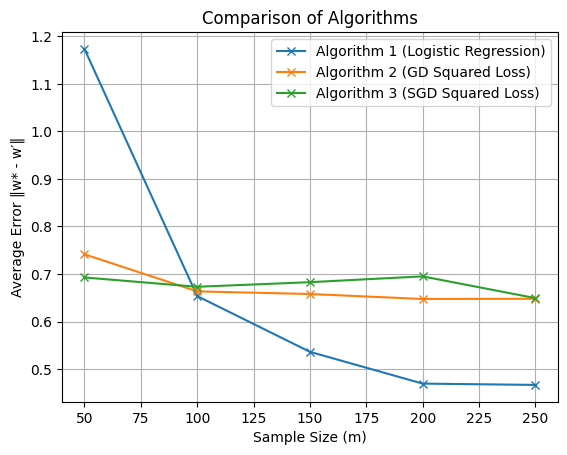

In [6]:
samples = [50, 100, 150, 200, 250]

start = time.time()
avg_errors_list_1 = []
for m in samples:
    errors = []
    for i in range(10):
        w_star, X, y = generate_data(m)
        clf.fit(X, y)
        w_prime = clf.coef_.flatten()
        error = np.linalg.norm(w_star - w_prime)
        errors.append(error)
    avg_error = np.mean(errors)
    avg_errors_list_1.append(avg_error)
end = time.time()
print(f"time_taken for Algorithm 1 ={end-start}")

start = time.time()
avg_errors_list_gd = []
for m in samples:
    errors = []
    for i in range(10):
        w_star, X, y = generate_data(m)
        w_prime, losses = gradient_descent_squared_loss(X,y)
        error = np.linalg.norm(w_star - w_prime)
        errors.append(error)
    avg_error = np.mean(errors)
    avg_errors_list_gd.append(avg_error)
end = time.time()
print(f"time_taken by Algorithm 2 ={end-start}")
# print(avg_errors_list)

#Compute Algorithm 3
start = time.time()
avg_errors_list_sgd = []
for m in samples:
    errors = []
    for i in range(10):
        w_star, X, y = generate_data(m)
        w_prime, losses = sgd_squared_loss(X,y)
        error = np.linalg.norm(w_star - w_prime)
        errors.append(error)
    avg_error = np.mean(errors)
    avg_errors_list_sgd.append(avg_error)
end = time.time()
print(f"time_taken for Algorithm 3 ={end-start}")
avg_errors_list_1
plt.plot(samples, avg_errors_list_1, marker="x", linestyle="-", label="Algorithm 1 (Logistic Regression)")
plt.plot(samples, avg_errors_list_gd, marker="x", linestyle="-", label="Algorithm 2 (GD Squared Loss)")
plt.plot(samples, avg_errors_list_sgd, marker="x", linestyle="-", label="Algorithm 3 (SGD Squared Loss)")

plt.xlabel("Sample Size (m)")
plt.ylabel("Average Error ‖w* - w′‖")
plt.title("Comparison of Algorithms")
plt.legend()
plt.grid(True)
plt.show()    


# Problem 2

In [7]:
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

In [8]:
cancer = datasets.load_breast_cancer()

For each depth in $1, \dots, 5$, instantiate an AdaBoost classifier with the base learner set to be a decision tree of that depth (set `n_estimators=10` and `learning_rate=1`), and then record the 10-fold cross-validated error on the entire breast cancer data set. Plot the resulting curve of accuracy against base classifier depth. Use $101$ as your random state for both the base learner as well as the AdaBoost classifier every time.

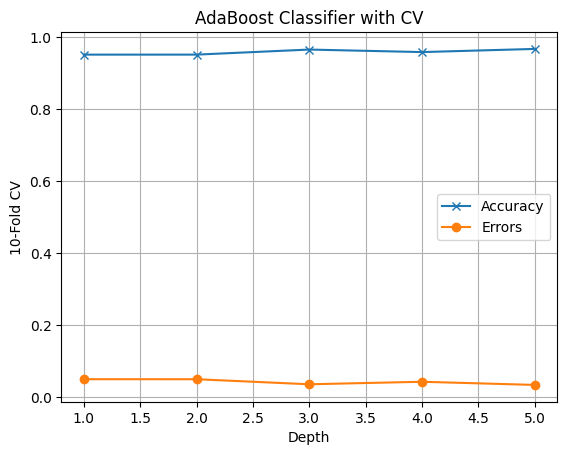

In [9]:
X, y = cancer.data, cancer.target

depths = [1,2,3,4,5]
errors = []
accuracies = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=101)
    abc = AdaBoostClassifier(estimator=clf, n_estimators=10, learning_rate=1, random_state=101)
    score = cross_val_score(abc, X, y, cv=10)
    acc = score.mean()
    accuracies.append(acc)
    errors.append(1 - acc)

plt.plot(depths, accuracies, marker='x', linestyle="-", label="Accuracy")
plt.plot(depths, errors, marker='o', linestyle="-", label="Errors")
plt.xlabel("Depth")
plt.ylabel("10-Fold CV")
plt.title("AdaBoost Classifier with CV")
plt.legend()
plt.grid(True)
plt.show()
